# Model Comparison — Predicting Potential Lloyds Customers

---

## Step 1 — Import Libraries

In [60]:
import sys
!{sys.executable} -m pip install xgboost shap scikit-learn pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.linear_model    import LogisticRegression
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report, roc_curve,
    confusion_matrix, precision_score, recall_score, f1_score
)

print('Libraries loaded successfully')

Libraries loaded successfully


---
## Step 2 — Load Data

In [61]:
# ── CHANGE THIS PATH TO WHERE YOUR flat.csv IS ───────────────────
CSV_PATH    = "/Users/patorn/Desktop/flat_pot.csv"
OUTPUT_PATH = '/Users/patorn/Downloads/model_comparison_lead_list.csv'
# ─────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH, dtype=str)

print(f'Rows:    {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head()

Rows:    356,047
Columns: ['com_num', 'name', 'sector', 'region', 'account_type', 'accounts_overdue', 'nonlloyds_charges', 'has_nonlloyds_charge', 'yrs_since_nonlloyds_chg', 'n_distinct_lenders', 'n_charges_last_24m', 'n_outstanding', 'n_satisfied', 'yrs_since_satisfaction', 'age_years', 'readmitted', 'label']


,com_num,name,sector,region,account_type,accounts_overdue,nonlloyds_charges,has_nonlloyds_charge,yrs_since_nonlloyds_chg,n_distinct_lenders,n_charges_last_24m,n_outstanding,n_satisfied,yrs_since_satisfaction,age_years,readmitted,label
0,07852962,369 UPLAND ROAD RTM COMPANY LIMITED,L: Real Estate,London,micro-entity,0,0,0,50.0,0,0,0,0,50.0,9.122518822724162,0,0
1,12047798,36A TACHBROOK STREET LIMITED,S: Other Services,London,micro-entity,0,0,0,50.0,0,0,0,0,50.0,1.5578370978781657,0,0
2,10379693,36ALPHA LTD,J: Information/Comms,London,micro-entity,0,0,0,50.0,0,0,0,0,50.0,4.292950034223135,0,0
3,07127657,36DIGITAL LIMITED,J: Information/Comms,East of England,micro-entity,0,0,0,50.0,0,0,0,0,50.0,10.959616700889802,0,0
4,10812571,36EL LTD,L: Real Estate,London,micro-entity,1,2,1,3.479808350444901,1,0,2,0,50.0,3.564681724845996,0,0


---
## Step 3 — Convert Numeric Columns

Convert text to numbers. **No other transformation — values used exactly as they appear in the file.**

In [62]:
numeric_cols = [
    'nonlloyds_charges',
    'has_nonlloyds_charge',
    'yrs_since_nonlloyds_chg',
    'n_distinct_lenders',
    'n_charges_last_24m',
    'n_outstanding',
    'n_satisfied',
    'yrs_since_satisfaction',
    'age_years',
    'accounts_overdue',
    'label',
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['label'] = df['label'].fillna(0).astype(int)

print(f'Positives (Lloyds customers): {df["label"].sum():,}')
print(f'Negatives (not Lloyds):       {(df["label"]==0).sum():,}')
print(f'Positive rate:                {df["label"].mean():.2%}')

Positives (Lloyds customers): 1,315
Negatives (not Lloyds):       354,732
Positive rate:                0.37%


---
## Step 4 — Encode Categorical Columns

| Column | Method | Why |
|---|---|---|
| `account_type` | Ordinal (0-4) | Has a natural size order — micro is smaller than medium |
| `sector` | One-hot | No natural order between industries |
| `region` | One-hot | No natural order between regions |

In [63]:
# account_type — ordinal encoding
account_order = {
    'micro-entity'          : 0,
    'total-exemption-small' : 1,
    'total-exemption-full'  : 2,
    'small'                 : 3,
    'medium'                : 4,
}
df['account_type_enc'] = df['account_type'].map(account_order).fillna(2)

# sector — one-hot encoding
sector_dummies = pd.get_dummies(df['sector'], prefix='sector')
df = pd.concat([df, sector_dummies], axis=1)

# region — one-hot encoding
df['region'] = df['region'].fillna('Unknown')
region_dummies = pd.get_dummies(df['region'], prefix='region')
df = pd.concat([df, region_dummies], axis=1)

print('Encoding complete.')
print(f'Sector columns: {len(sector_dummies.columns)}')
print(f'Region columns: {len(region_dummies.columns)}')

Encoding complete.
Sector columns: 21
Region columns: 13


---
## Step 5 — Build Feature List

All three models use exactly the same features. This is what makes the comparison fair.

In [64]:
feature_cols = (
    [
        # Numeric — raw values as in the CSV
        'age_years',
        'nonlloyds_charges',
        'has_nonlloyds_charge',
        'yrs_since_nonlloyds_chg',
        'n_distinct_lenders',
        'accounts_overdue',
        # Encoded categorical
        'account_type_enc',
        'n_charges_last_24m',
        'n_outstanding',
        'n_satisfied',
        'yrs_since_satisfaction',
    ]
    + list(sector_dummies.columns)
    + list(region_dummies.columns)
)

X = df[feature_cols].astype(float)
y = df['label']

print(f'Total features used by all models: {len(feature_cols)}')
print()
for f in feature_cols:
    print(f'  {f}')

Total features used by all models: 45

  age_years
  nonlloyds_charges
  has_nonlloyds_charge
  yrs_since_nonlloyds_chg
  n_distinct_lenders
  accounts_overdue
  account_type_enc
  n_charges_last_24m
  n_outstanding
  n_satisfied
  yrs_since_satisfaction
  sector_A: Agriculture
  sector_B: Mining
  sector_C: Manufacturing
  sector_D: Utilities
  sector_E: Water/Waste
  sector_F: Construction
  sector_G: Retail/Wholesale
  sector_H: Transport
  sector_I: Accommodation/Food
  sector_J: Information/Comms
  sector_K: Finance/Insurance
  sector_L: Real Estate
  sector_M: Professional/Scientific
  sector_N: Admin Support
  sector_O: Public Admin
  sector_P: Education
  sector_Q: Health/Social
  sector_R: Arts/Recreation
  sector_S: Other Services
  sector_T: Household Activities
  sector_U: Extraterritorial
  region_East Midlands
  region_East of England
  region_London
  region_North East
  region_North West
  region_Northern Ireland
  region_Scotland
  region_South East
  region_South West

---
## Step 6 — Train / Test Split (80/20 Stratified)

`random_state=42` and `stratify=y` are fixed so all three models train and test on **exactly the same rows**. This is essential for a fair comparison.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    stratify     = y,
    random_state = 42,
)

print(f'{"Set":<10} {"Rows":>10} {"Positives":>10} {"Pos rate":>10}')
print('-' * 45)
for name, y_s in [('Train', y_train), ('Test', y_test)]:
    print(f'{name:<10} {len(y_s):>10,} {int(y_s.sum()):>10} {y_s.mean():>10.2%}')

Set              Rows  Positives   Pos rate
---------------------------------------------
Train         284,837       1052      0.37%
Test           71,210        263      0.37%


---
## Step 7 — Helper Functions

Shared evaluation functions used by all three models.

In [66]:
def precision_at_k(y_true, y_prob, k):
    """Of the top K scored companies, what fraction are real Lloyds customers?"""
    top_k = np.argsort(y_prob)[::-1][:k]
    return np.array(y_true)[top_k].mean()


def evaluate_model(name, y_test, test_prob, baseline):
    """Print full evaluation for one model."""
    test_pred = (test_prob >= 0.5).astype(int)
    test_auc  = roc_auc_score(y_test, test_prob)
    cm        = confusion_matrix(y_test, test_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f'{'=' * 55}')
    print(f'  {name}')
    print(f'{'=' * 55}')
    print(f'  Test AUC : {test_auc:.3f}')
    print()
    print(f'  Confusion Matrix:')
    print(f'    TP = {tp:,}   FP = {fp:,}')
    print(f'    FN = {fn:,}   TN = {tn:,}')
    print()
    print(f'  Precision = {tp/(tp+fp):.3f}' if (tp+fp)>0 else '  Precision = n/a')
    print(f'  Recall    = {tp/(tp+fn):.3f}' if (tp+fn)>0 else '  Recall = n/a')
    print(f'  F1        = {f1_score(y_test, test_pred, zero_division=0):.3f}')
    print()

    results = {}
    for k in [10, 20, 50, 100, 200, 500, 1000]:
        if len(test_prob) >= k:
            p    = precision_at_k(y_test, test_prob, k)
            lift = p / baseline if baseline > 0 else 0
            real = int(round(p * k))
            results[k] = {'precision': p, 'lift': lift, 'real': real}
            print(f'  Precision@{k:<5} {p:>6.1%}   {lift:>5.1f}x   {real} real')

    return {
        'auc'       : test_auc,
        'tp'        : tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision' : precision_score(y_test, test_pred, zero_division=0),
        'recall'    : recall_score(y_test, test_pred, zero_division=0),
        'f1'        : f1_score(y_test, test_pred, zero_division=0),
        'prec_at_k' : results,
        'prob'      : test_prob,
    }


baseline = y_test.mean()
print(f'Baseline positive rate: {baseline:.2%}')
print('Helper functions ready.')

Baseline positive rate: 0.37%
Helper functions ready.


---
## Step 8 — Train and Evaluate Model 1: Logistic Regression

- Needs `StandardScaler` — sensitive to feature scale
- `class_weight='balanced'` handles the 2.7% imbalance
- Most interpretable — produces one coefficient per feature

In [67]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(
        class_weight = 'balanced',
        max_iter     = 1000,
        C            = 1.0,
        solver       = 'lbfgs',
        random_state = 42,
    ))
])

lr_model.fit(X_train, y_train)
lr_prob    = lr_model.predict_proba(X_test)[:, 1]
lr_results = evaluate_model('LOGISTIC REGRESSION', y_test, lr_prob, baseline)

  LOGISTIC REGRESSION
  Test AUC : 0.768

  Confusion Matrix:
    TP = 187   FP = 22,667
    FN = 76   TN = 48,280

  Precision = 0.008
  Recall    = 0.711
  F1        = 0.016

  Precision@10      0.0%     0.0x   0 real
  Precision@20      0.0%     0.0x   0 real
  Precision@50      2.0%     5.4x   1 real
  Precision@100     2.0%     5.4x   2 real
  Precision@200     1.5%     4.1x   3 real
  Precision@500     2.2%     6.0x   11 real
  Precision@1000    2.0%     5.4x   20 real


---
## Step 9 — Train and Evaluate Model 2: XGBoost

- Does NOT need `StandardScaler` — trees are scale-invariant
- `scale_pos_weight` handles the imbalance
- Captures non-linear patterns and feature interactions

In [68]:
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
scale = n_neg / n_pos

xgb_model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale,
    eval_metric      = 'auc',
    random_state     = 42,
    verbosity        = 0,
)

xgb_model.fit(X_train, y_train)
xgb_prob    = xgb_model.predict_proba(X_test)[:, 1]
xgb_results = evaluate_model('XGBOOST', y_test, xgb_prob, baseline)

  XGBOOST
  Test AUC : 0.769

  Confusion Matrix:
    TP = 175   FP = 19,135
    FN = 88   TN = 51,812

  Precision = 0.009
  Recall    = 0.665
  F1        = 0.018

  Precision@10      0.0%     0.0x   0 real
  Precision@20      0.0%     0.0x   0 real
  Precision@50      4.0%    10.8x   2 real
  Precision@100     4.0%    10.8x   4 real
  Precision@200     3.5%     9.5x   7 real
  Precision@500     2.8%     7.6x   14 real
  Precision@1000    2.1%     5.7x   21 real


---
## Step 10 — Train and Evaluate Model 3: Neural Network

- Needs `StandardScaler` — sensitive to feature scale
- `sample_weight` handles the imbalance
- Architecture: Input → 64 neurons → 32 neurons → Output
- `early_stopping=True` stops when validation score stops improving

In [69]:
sample_weights = np.array([1.0 if label == 0 else n_neg/n_pos
                           for label in y_train])

nn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('nn',     MLPClassifier(
        hidden_layer_sizes  = (64, 32),
        activation          = 'relu',
        solver              = 'adam',
        alpha               = 0.01,
        max_iter            = 300,
        early_stopping      = True,
        validation_fraction = 0.1,
        random_state        = 42,
        verbose             = False,
    ))
])

nn_model.fit(X_train, y_train,
             nn__sample_weight=sample_weights)

print(f'Stopped at iteration: {nn_model.named_steps["nn"].n_iter_}')

nn_prob    = nn_model.predict_proba(X_test)[:, 1]
nn_results = evaluate_model('NEURAL NETWORK', y_test, nn_prob, baseline)

Stopped at iteration: 15
  NEURAL NETWORK
  Test AUC : 0.767

  Confusion Matrix:
    TP = 139   FP = 14,757
    FN = 124   TN = 56,190

  Precision = 0.009
  Recall    = 0.529
  F1        = 0.018

  Precision@10      0.0%     0.0x   0 real
  Precision@20      0.0%     0.0x   0 real
  Precision@50      0.0%     0.0x   0 real
  Precision@100     1.0%     2.7x   1 real
  Precision@200     2.0%     5.4x   4 real
  Precision@500     2.0%     5.4x   10 real
  Precision@1000    1.5%     4.1x   15 real


---
## Step 11 — Head to Head Comparison Table

In [70]:
comparison = pd.DataFrame({
    'Metric': [
        'Test AUC',
        'True Positives (TP)',
        'False Positives (FP)',
        'False Negatives (FN)',
        'True Negatives (TN)',
        'Precision',
        'Recall',
        'F1 Score',
        'Precision@10',
        'Precision@50',
        'Precision@100',
        'Precision@500',
    ],
    'Logistic Regression': [
        f"{lr_results['auc']:.3f}",
        f"{lr_results['tp']:,}",
        f"{lr_results['fp']:,}",
        f"{lr_results['fn']:,}",
        f"{lr_results['tn']:,}",
        f"{lr_results['precision']:.3f}",
        f"{lr_results['recall']:.3f}",
        f"{lr_results['f1']:.3f}",
        f"{lr_results['prec_at_k'].get(10,  {}).get('precision', 0):.1%}",
        f"{lr_results['prec_at_k'].get(50,  {}).get('precision', 0):.1%}",
        f"{lr_results['prec_at_k'].get(100, {}).get('precision', 0):.1%}",
        f"{lr_results['prec_at_k'].get(500, {}).get('precision', 0):.1%}",
    ],
    'XGBoost': [
        f"{xgb_results['auc']:.3f}",
        f"{xgb_results['tp']:,}",
        f"{xgb_results['fp']:,}",
        f"{xgb_results['fn']:,}",
        f"{xgb_results['tn']:,}",
        f"{xgb_results['precision']:.3f}",
        f"{xgb_results['recall']:.3f}",
        f"{xgb_results['f1']:.3f}",
        f"{xgb_results['prec_at_k'].get(10,  {}).get('precision', 0):.1%}",
        f"{xgb_results['prec_at_k'].get(50,  {}).get('precision', 0):.1%}",
        f"{xgb_results['prec_at_k'].get(100, {}).get('precision', 0):.1%}",
        f"{xgb_results['prec_at_k'].get(500, {}).get('precision', 0):.1%}",
    ],
    'Neural Network': [
        f"{nn_results['auc']:.3f}",
        f"{nn_results['tp']:,}",
        f"{nn_results['fp']:,}",
        f"{nn_results['fn']:,}",
        f"{nn_results['tn']:,}",
        f"{nn_results['precision']:.3f}",
        f"{nn_results['recall']:.3f}",
        f"{nn_results['f1']:.3f}",
        f"{nn_results['prec_at_k'].get(10,  {}).get('precision', 0):.1%}",
        f"{nn_results['prec_at_k'].get(50,  {}).get('precision', 0):.1%}",
        f"{nn_results['prec_at_k'].get(100, {}).get('precision', 0):.1%}",
        f"{nn_results['prec_at_k'].get(500, {}).get('precision', 0):.1%}",
    ],
})

print('HEAD TO HEAD COMPARISON')
comparison

HEAD TO HEAD COMPARISON


,Metric,Logistic Regression,XGBoost,Neural Network
0,Test AUC,0.768,0.769,0.767
1,True Positives (TP),187,175,139
2,False Positives (FP),"22,667","19,135","14,757"
3,False Negatives (FN),76,88,124
4,True Negatives (TN),"48,280","51,812","56,190"
5,Precision,0.008,0.009,0.009
6,Recall,0.711,0.665,0.529
7,F1 Score,0.016,0.018,0.018
8,Precision@10,0.0%,0.0%,0.0%
9,Precision@50,2.0%,4.0%,0.0%


---
## Step 12 — ROC Curves (All Three on One Chart)

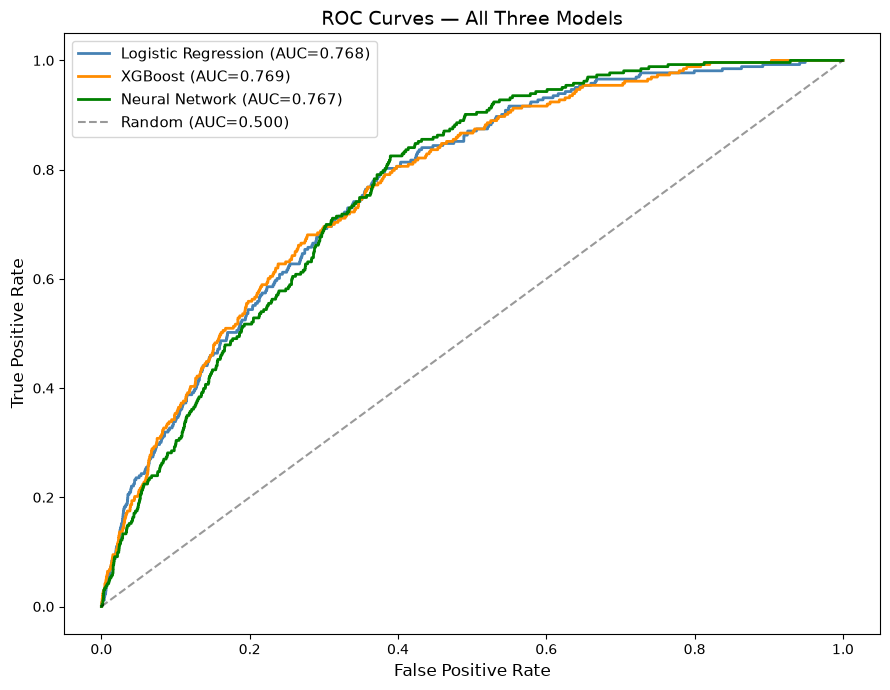

In [71]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, prob, color in [
    ('Logistic Regression', lr_prob,  'steelblue'),
    ('XGBoost',             xgb_prob, 'darkorange'),
    ('Neural Network',      nn_prob,  'green'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc         = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Three Models', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 13 — Confusion Matrices (Side by Side)

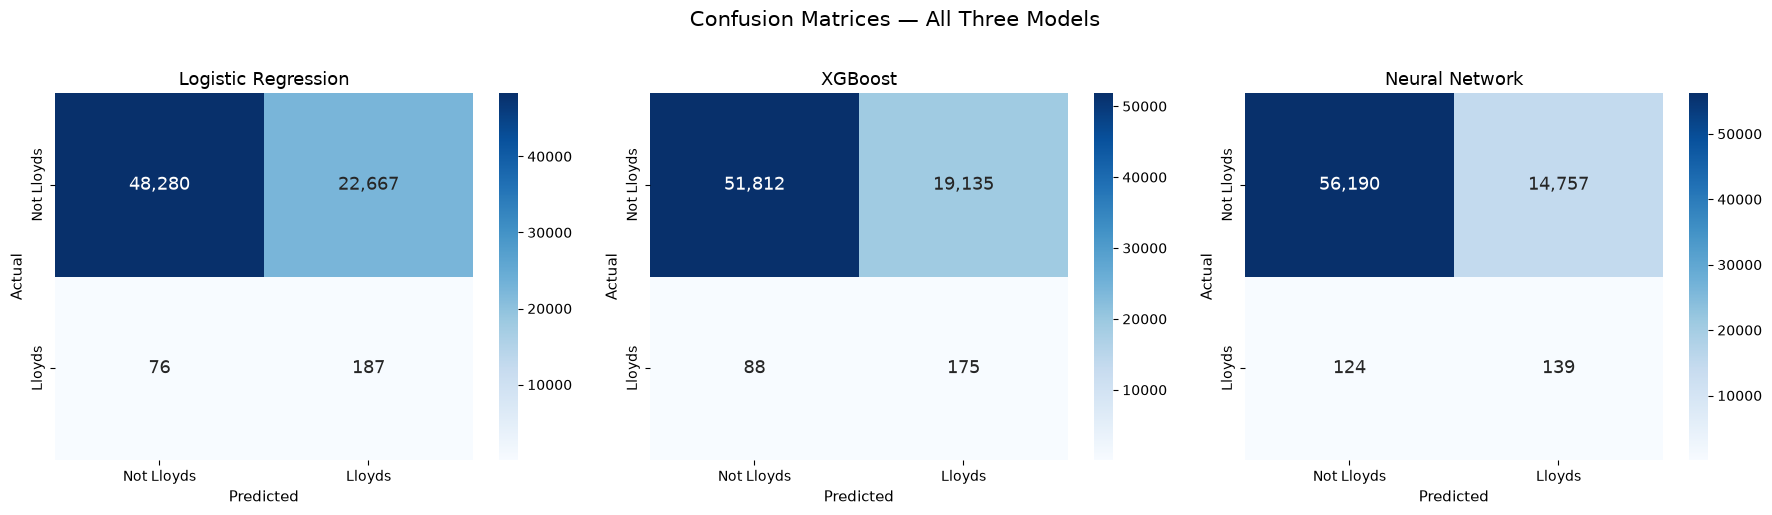

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, prob in zip(
    axes,
    ['Logistic Regression', 'XGBoost', 'Neural Network'],
    [lr_prob, xgb_prob, nn_prob]
):
    pred = (prob >= 0.5).astype(int)
    cm   = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt=',d', cmap='Blues',
        xticklabels=['Not Lloyds', 'Lloyds'],
        yticklabels=['Not Lloyds', 'Lloyds'],
        ax=ax, annot_kws={'size': 13},
    )
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(name, fontsize=13)

plt.suptitle('Confusion Matrices — All Three Models', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 14 — Precision@K Curves (All Three on One Chart)

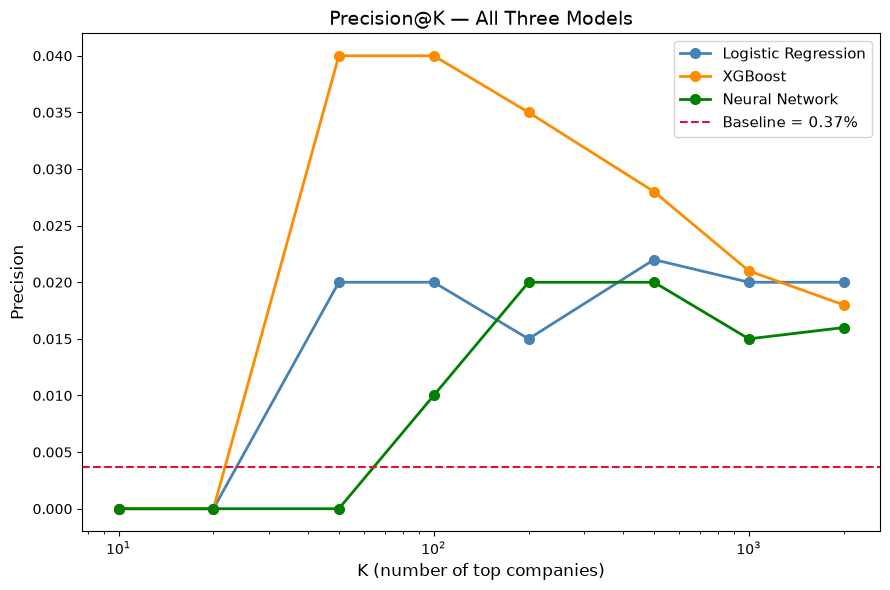

In [73]:
ks = [10, 20, 50, 100, 200, 500, 1000, 2000]

fig, ax = plt.subplots(figsize=(9, 6))

for name, prob, color in [
    ('Logistic Regression', lr_prob,  'steelblue'),
    ('XGBoost',             xgb_prob, 'darkorange'),
    ('Neural Network',      nn_prob,  'green'),
]:
    prec_at_k = [precision_at_k(y_test, prob, k)
                 for k in ks if len(prob) >= k]
    valid_ks  = [k for k in ks if len(prob) >= k]
    ax.plot(valid_ks, prec_at_k, 'o-', color=color,
            linewidth=2, markersize=7, label=name)

ax.axhline(baseline, color='crimson', linestyle='--',
           label=f'Baseline = {baseline:.2%}')
ax.set_xlabel('K (number of top companies)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision@K — All Three Models', fontsize=14)
ax.legend(fontsize=11)
ax.set_xscale('log')
plt.tight_layout()
plt.show()

---
## Step 15 — Explainability

### 15a — Logistic Regression Coefficients
Each coefficient shows how much a feature pushes a company toward or away from being a Lloyds customer.

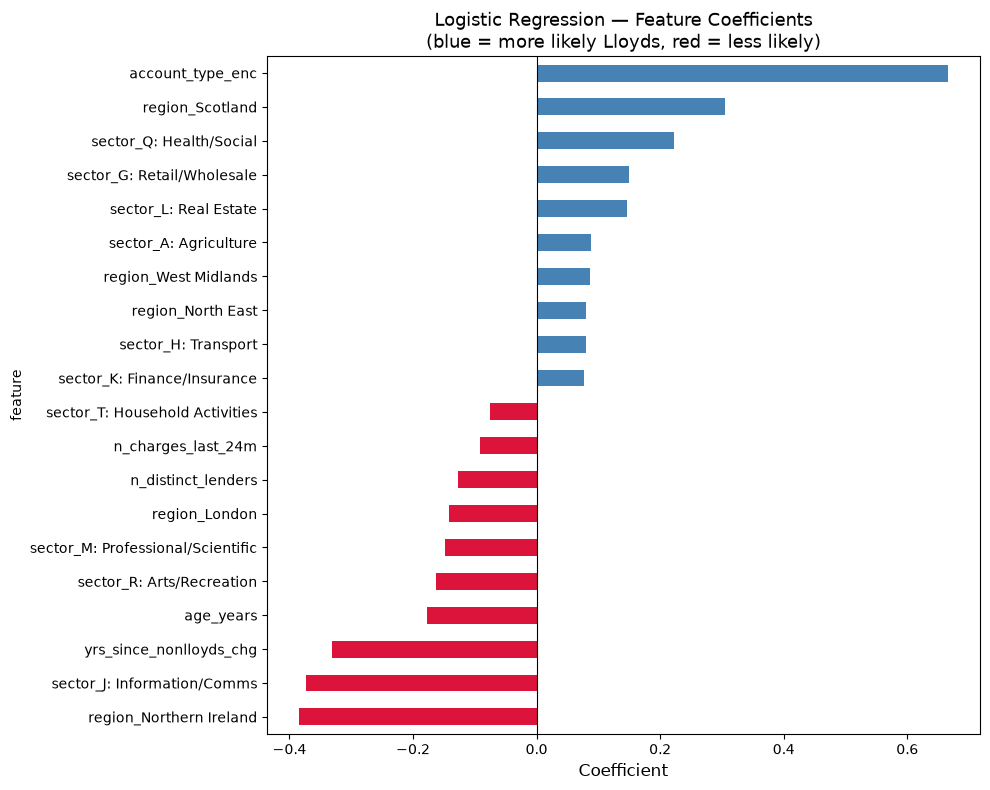

In [74]:
coefs = pd.DataFrame({
    'feature'    : feature_cols,
    'coefficient': lr_model.named_steps['lr'].coef_[0],
}).sort_values('coefficient', ascending=False)

top_coefs = pd.concat([coefs.head(10), coefs.tail(10)]).drop_duplicates('feature')
coef_plot = top_coefs.set_index('feature')['coefficient'].sort_values()
colors    = ['crimson' if v < 0 else 'steelblue' for v in coef_plot]

fig, ax = plt.subplots(figsize=(10, 8))
coef_plot.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients\n(blue = more likely Lloyds, red = less likely)',
             fontsize=13)
ax.set_xlabel('Coefficient', fontsize=12)
plt.tight_layout()
plt.show()

### 15b — XGBoost Feature Importance

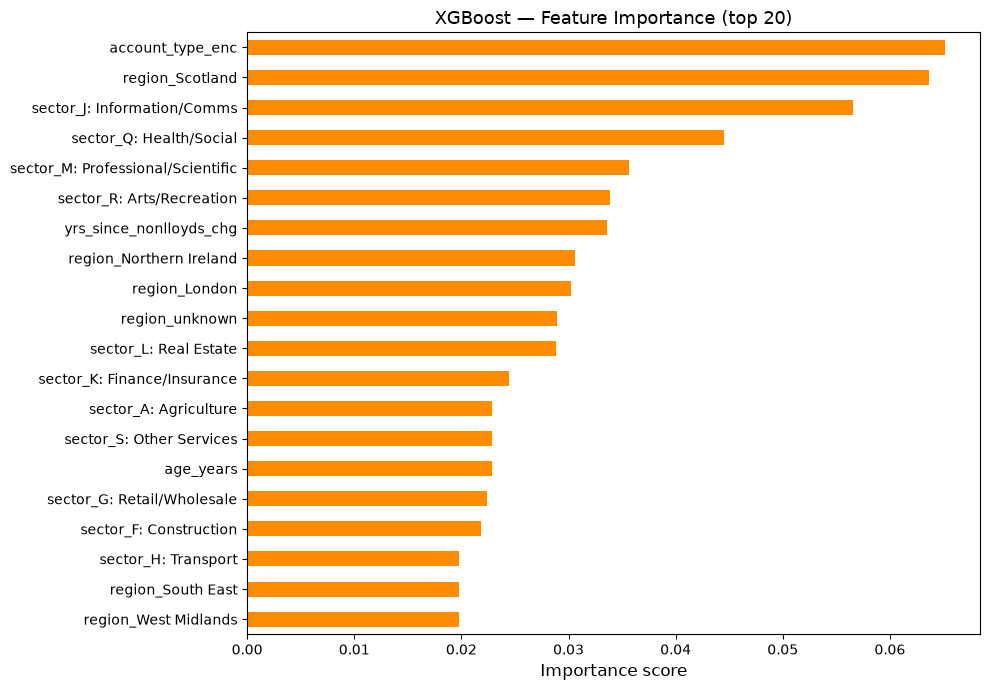

In [75]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('XGBoost — Feature Importance (top 20)', fontsize=13)
ax.set_xlabel('Importance score', fontsize=12)
plt.tight_layout()
plt.show()

### 15c — XGBoost SHAP Values

SHAP values show how much each feature pushed each individual company's score up or down. Red = high feature value, Blue = low feature value.

Calculating SHAP values (may take a minute)...


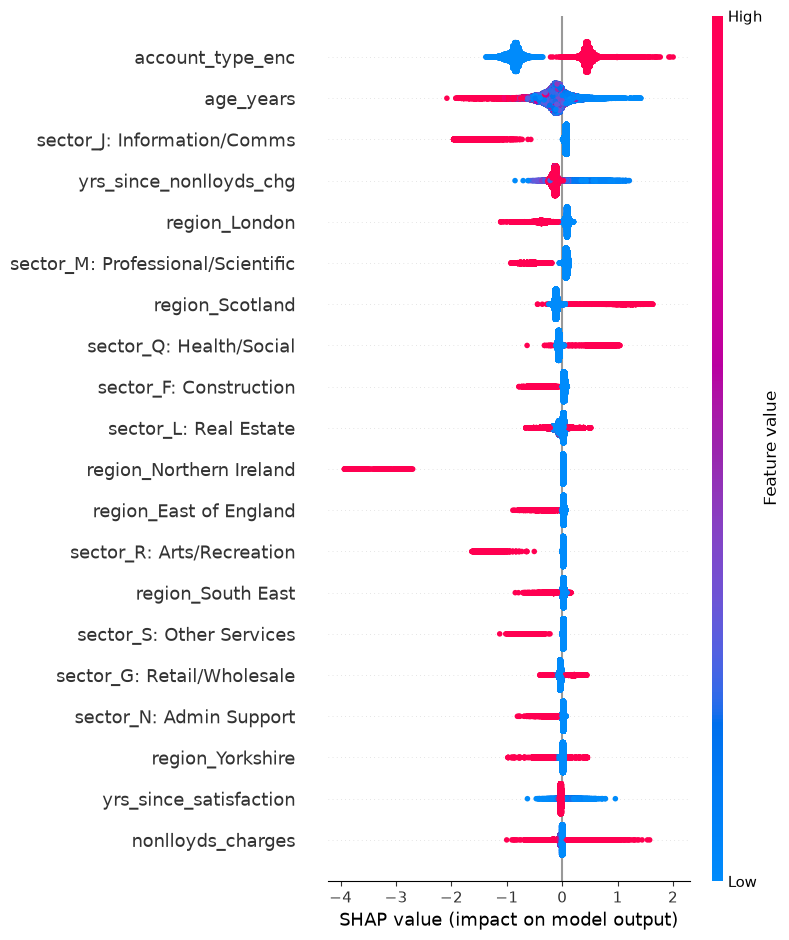

In [76]:
print('Calculating SHAP values (may take a minute)...')
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_cols,
    show=True
)

### 15d — Neural Network Training Loss Curve

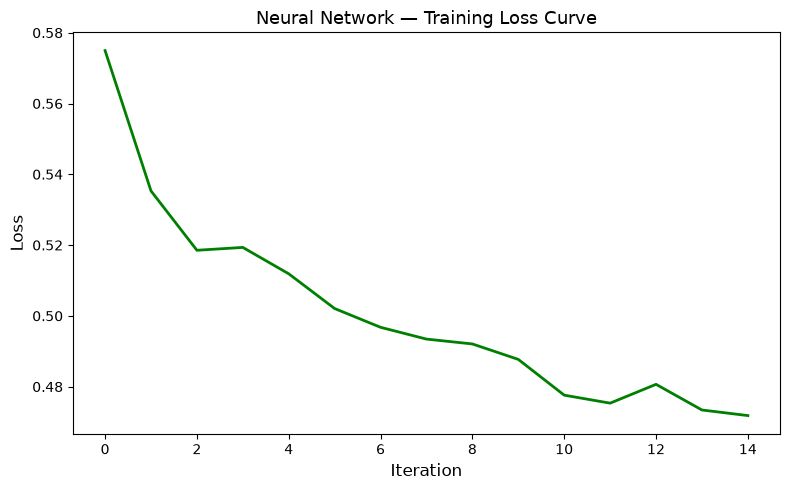

Started at loss : 0.5750
Ended at loss   : 0.4718
Total iterations: 15


In [77]:
loss_curve = nn_model.named_steps['nn'].loss_curve_

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(loss_curve, color='green', linewidth=2)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Neural Network — Training Loss Curve', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Started at loss : {loss_curve[0]:.4f}')
print(f'Ended at loss   : {loss_curve[-1]:.4f}')
print(f'Total iterations: {len(loss_curve)}')

---
## Step 16 — Save Ranked Lead List

Score all companies with all three models. The final lead list includes a propensity score and tier from each model so you can see where they agree and disagree.

In [78]:
df['lr_score']  = lr_model.predict_proba(X)[:, 1]
df['xgb_score'] = xgb_model.predict_proba(X)[:, 1]
df['nn_score']  = nn_model.predict_proba(X)[:, 1]

def tier(score):
    if score >= 0.70: return 'VERY HIGH'
    if score >= 0.50: return 'HIGH'
    if score >= 0.30: return 'MEDIUM'
    return 'LOW'

df['lr_tier']  = df['lr_score'].apply(tier)
df['xgb_tier'] = df['xgb_score'].apply(tier)
df['nn_tier']  = df['nn_score'].apply(tier)

# Use XGBoost score as primary ranking (usually strongest)
df['primary_score'] = df['xgb_score']

keep = ['com_num', 'name', 'sector', 'region', 'account_type',
        'age_years', 'nonlloyds_charges', 'n_distinct_lenders',
        'has_nonlloyds_charge', 'yrs_since_nonlloyds_chg',
        'label',
        'lr_score',  'lr_tier',
        'xgb_score', 'xgb_tier',
        'nn_score',  'nn_tier',
        'primary_score']
keep = [c for c in keep if c in df.columns]

lead_list = df[keep].sort_values('primary_score', ascending=False)
lead_list.to_csv(OUTPUT_PATH, index=False)

print(f'Saved {OUTPUT_PATH}')
print()
print('XGBoost tier breakdown (primary ranking):')
print(f'  VERY HIGH (>0.70): {(df["xgb_tier"]=="VERY HIGH").sum():,}')
print(f'  HIGH (0.50-0.70):  {(df["xgb_tier"]=="HIGH").sum():,}')
print(f'  MEDIUM (0.30-0.50):{(df["xgb_tier"]=="MEDIUM").sum():,}')
print(f'  LOW (<0.30):       {(df["xgb_tier"]=="LOW").sum():,}')
print()
print('Top 10 companies (ranked by XGBoost score):')
lead_list.head(10)

Saved /Users/patorn/Downloads/model_comparison_lead_list.csv

XGBoost tier breakdown (primary ranking):
  VERY HIGH (>0.70): 27,192
  HIGH (0.50-0.70):  69,607
  MEDIUM (0.30-0.50):86,315
  LOW (<0.30):       172,933

Top 10 companies (ranked by XGBoost score):


,com_num,name,sector,region,account_type,age_years,nonlloyds_charges,n_distinct_lenders,has_nonlloyds_charge,yrs_since_nonlloyds_chg,label,lr_score,lr_tier,xgb_score,xgb_tier,nn_score,nn_tier,primary_score
204285,SC514287,CASTLE WATER (SCOTLAND) NO.2 LIMITED,E: Water/Waste,Scotland,small,5.347023,1,1,1,3.457906,0,0.980989,VERY HIGH,0.953249,VERY HIGH,0.970867,VERY HIGH,0.953249
99445,SC173743,ANCASTER COURT LIMITED,L: Real Estate,Scotland,total-exemption-full,23.775496,19,2,1,5.990418,1,0.964516,VERY HIGH,0.952653,VERY HIGH,0.899990,VERY HIGH,0.952653
47473,SC387609,ADAM BUCHANAN SMITH LIMITED,I: Accommodation/Food,Scotland,medium,10.187543,0,0,0,50.000000,0,0.953960,VERY HIGH,0.949400,VERY HIGH,0.883989,VERY HIGH,0.949400
229093,09625822,DRIFTWOOD & BLUE PLYMOUTH LIMITED,L: Real Estate,London,total-exemption-full,5.577002,16,1,1,5.040383,0,0.835162,VERY HIGH,0.949221,VERY HIGH,0.865342,VERY HIGH,0.949221
88087,SC477637,ALTEA 4 RESTAURANTS LTD,G: Retail/Wholesale,Scotland,medium,6.636550,0,0,0,50.000000,0,0.965590,VERY HIGH,0.948581,VERY HIGH,0.865979,VERY HIGH,0.948581
26489,12374490,A.V. DAWSON TRANSPORT LTD,H: Transport,North East,medium,1.034908,0,0,0,50.000000,1,0.926408,VERY HIGH,0.947263,VERY HIGH,0.874592,VERY HIGH,0.947263
268886,SC682837,ID1 GROUP LTD,L: Real Estate,Scotland,total-exemption-full,0.076660,0,0,0,50.000000,0,0.887359,VERY HIGH,0.945763,VERY HIGH,0.814844,VERY HIGH,0.945763
126233,SC555605,ARMSTRONG RENEWABLES (SCOTLAND) LIMITED,E: Water/Waste,Scotland,small,3.934292,0,0,0,50.000000,0,0.959187,VERY HIGH,0.944871,VERY HIGH,0.963937,VERY HIGH,0.944871
57630,SC681885,AFDAK INVESTMENTS LTD,L: Real Estate,Scotland,total-exemption-full,0.101300,0,0,0,50.000000,0,0.887318,VERY HIGH,0.944479,VERY HIGH,0.814766,VERY HIGH,0.944479
110772,SC457177,AONE DENTAL PRACTICES LIMITED,Q: Health/Social,Scotland,total-exemption-full,7.367556,2,1,1,2.713210,0,0.971579,VERY HIGH,0.944171,VERY HIGH,0.898850,VERY HIGH,0.944171


---
## Summary

| | Logistic Regression | XGBoost | Neural Network |
|---|---|---|---|
| Needs scaling | Yes | No | Yes |
| Handles imbalance | `class_weight` | `scale_pos_weight` | `sample_weight` |
| Explainability | Coefficients | Importance + SHAP | Loss curve only |
| Captures non-linear patterns | No | Yes | Yes |
| Speed | Fastest | Medium | Slowest |

**How to pick the best model:**
- Highest AUC → best overall ranking quality
- Highest Precision@50 → best for a small focused outreach list
- If AUC is similar → choose Logistic Regression or XGBoost for explainability
- Neural Network may beat the others if it captures complex feature interactions that the others miss